# Implementación de Backpropagation y Funciones de Activación

En esta práctica se implementa una red neuronal simple entrenable
para observar cómo los pesos se ajustan mediante backpropagation.

También se comparan dos funciones de activación:

- Sigmoid
- ReLU

El objetivo es analizar cómo cambia el proceso de aprendizaje
y la evolución del error (loss) durante el entrenamiento.

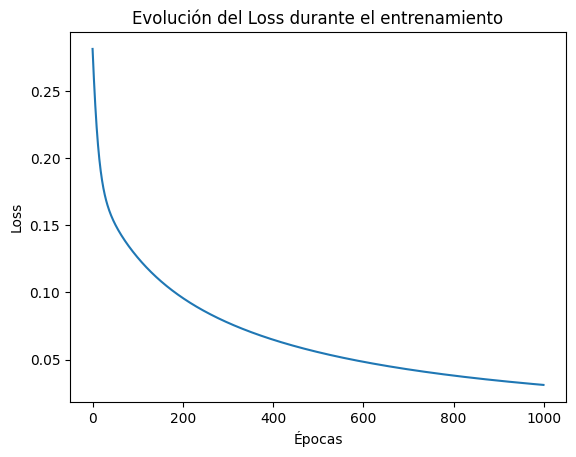

Predicciones con Sigmoid:
[[0.01598281]
 [0.18908585]
 [0.18895163]
 [0.76982649]]

Predicciones usando ReLU:
[[0.        ]
 [0.        ]
 [0.        ]
 [1.20733176]]


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Dataset (AND lógico)
# -----------------------------
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([
    [0],
    [0],
    [0],
    [1]
])

# -----------------------------
# Funciones de activación
# -----------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

# -----------------------------
# Inicialización de pesos
# -----------------------------
np.random.seed(1)

weights = np.random.rand(2,1)
bias = np.random.rand(1)

# -----------------------------
# Parámetros de entrenamiento
# -----------------------------
learning_rate = 0.1
epochs = 1000
losses = []

# -----------------------------
# Entrenamiento (Backpropagation)
# -----------------------------
for epoch in range(epochs):

    # Forward propagation
    z = np.dot(X, weights) + bias
    output = sigmoid(z)

    # Error
    error = y - output

    # Loss (error cuadrático medio)
    loss = np.mean(error**2)
    losses.append(loss)

    # Backpropagation
    d_output = error * sigmoid_derivative(output)

    weights += learning_rate * np.dot(X.T, d_output)
    bias += learning_rate * np.sum(d_output)

# -----------------------------
# Gráfico de evolución del loss
# -----------------------------
plt.plot(losses)
plt.title("Evolución del Loss durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.show()

# -----------------------------
# Predicciones finales
# -----------------------------
z = np.dot(X, weights) + bias
predicciones_sigmoid = sigmoid(z)

print("Predicciones con Sigmoid:")
print(predicciones_sigmoid)

# -----------------------------
# Comparación con ReLU
# -----------------------------
predicciones_relu = relu(z)

print("\nPredicciones usando ReLU:")
print(predicciones_relu)

## Análisis de resultados

Se compararon dos funciones de activación: sigmoid y ReLU.

La función sigmoid produce salidas entre 0 y 1, lo que permite
interpretar las predicciones como probabilidades.

ReLU es más simple y eficiente computacionalmente, pero en
algunos casos puede generar neuronas inactivas si el valor
de entrada es negativo.

Durante el entrenamiento se observa que el loss disminuye
progresivamente, indicando que la red está aprendiendo
y ajustando sus parámetros mediante backpropagation.

## Conclusiones

El proceso de backpropagation permite que la red neuronal
ajuste sus pesos y bias para reducir el error durante
el entrenamiento.

Las funciones de activación influyen en el comportamiento
del modelo y en su capacidad de aprendizaje.

En este experimento se observó que ambas funciones permiten
aprender el patrón del dataset, aunque presentan diferencias
en la forma en que actualizan las salidas.